# 纯债基金久期测算系统

基于申万宏源《纯债基金久期全解析》研报的实现

## 功能说明
1. 读取基金样本数据，筛选符合条件的基金
2. 根据持仓情况表判断基金是利率债还是信用债
3. 通过Wind API获取基金后复权净值数据
4. 使用Lasso回归和带约束的WLS测算基金久期
5. 计算全市场基金久期中位数和分歧度

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import sys
import warnings
warnings.filterwarnings('ignore')

# 导入自定义模块
from data_preprocessing import FundDataPreprocessor
from fund_type_classifier import FundTypeClassifier
from wind_data_fetcher import WindDataFetcher
from bond_index_data import BondIndexDataProcessor
from duration_model import FundDurationCalculator

print('模块导入成功')

模块导入成功


## 1. 初始化各模块

In [2]:
# 1. 数据预处理器
preprocessor = FundDataPreprocessor(
    short_term_path='短期纯债基金样本数据.xlsx',
    medium_long_term_path='中长期纯债基金样本数据.xlsx'
)

# 2. 基金类型分类器
classifier = FundTypeClassifier(
    holdings_path='纯债基金持仓情况.xlsx'
)
classifier.load_holdings_data()

# 3. Wind数据获取器
wind_fetcher = WindDataFetcher()

# 4. 中债指数数据处理器
index_processor = BondIndexDataProcessor(
    index_path='中债财富指数.xlsx'
)
index_processor.load_price_data()
index_processor.load_duration_data()

print('所有模块初始化完成')

Welcome to use Wind Quant API for Python (WindPy)!

COPYRIGHT (C) 2024 WIND INFORMATION CO., LTD. ALL RIGHTS RESERVED.
IN NO CIRCUMSTANCE SHALL WIND BE RESPONSIBLE FOR ANY DAMAGES OR LOSSES CAUSED BY USING WIND QUANT API FOR Python.
Wind连接成功
所有模块初始化完成


## 2. 测试获取基金池

In [3]:
# 设置目标日期
# target_date = datetime.now().strftime('%Y-%m-%d')
target_date = '2026-06-12'
print(f'目标日期: {target_date}')

# 获取基金池
fund_pool = preprocessor.get_fund_pool(target_date)

print(f'\n短期纯债基金数量: {len(fund_pool["short"])}')
print(f'中长期纯债基金数量: {len(fund_pool["medium_long"])}')

# 显示前几只基金
print('\n短期基金样例:')
print(fund_pool['short'].head())

目标日期: 2026-06-12

短期纯债基金数量: 356
中长期纯债基金数量: 1221

短期基金样例:
        Code         Name fund_setupdate fund_maturitydate_2 fund_type  \
0  000084.OF        博时安盈A     2013-04-23                 NaT    契约型开放式   
2  000089.OF  民生加银高等级信用债C     2020-07-24                 NaT    契约型开放式   
4  000128.OF      大成景安短融A     2013-05-24                 NaT    契约型开放式   
6  000322.OF      农银汇理金汇A     2020-06-29                 NaT    契约型开放式   
7  000394.OF      融通通源短融A     2014-10-30                 NaT    契约型开放式   

  fund_valuationmethod fund_regulopenfundornot fund_initial  
0                  市值法                       否            是  
2                  市值法                       否            是  
4                  市值法                       否            是  
6                  市值法                       否            是  
7                  市值法                       否            是  


## 3. 测试基金类型判断

In [4]:
# 测试几只基金的类型
test_codes = ['000033.OF', '000032.OF']

for code in test_codes:
    fund_type = classifier.get_fund_type(code, target_date)
    print(f'{code}: {fund_type}')

000033.OF: credit
000032.OF: credit


## 4. 测试Wind数据获取

In [5]:
# 测试获取单只基金数据
test_code = '000033.OF'
start_date = (datetime.now() - timedelta(days=90)).strftime('%Y-%m-%d')

print(f'获取基金 {test_code} 从 {start_date} 到 {target_date} 的净值数据...')
nav_df = wind_fetcher.get_fund_nav_smoothed(test_code, start_date, target_date)

if nav_df is not None:
    print(f'成功获取 {len(nav_df)} 条数据')
    print(nav_df.head(10))

获取基金 000033.OF 从 2026-03-27 到 2026-06-12 的净值数据...
成功获取 52 条数据
               NAV  NAV_smooth    return
2026-03-27  1.1246    1.124600       NaN
2026-03-30  1.1250    1.124800  0.000178
2026-03-31  1.1252    1.124933  0.000119
2026-04-01  1.1250    1.124950  0.000015
2026-04-02  1.1251    1.124980  0.000027
2026-04-03  1.1258    1.125220  0.000213
2026-04-07  1.1262    1.125460  0.000213
2026-04-08  1.1262    1.125660  0.000178
2026-04-09  1.1260    1.125860  0.000178
2026-04-10  1.1261    1.126060  0.000178


## 5. 测试中债指数数据

In [6]:
# 查看中长期利率型指数
print('中长期利率型指数:')
print(index_processor.medium_long_rate_indices)

# 查看数据
test_prices = index_processor.get_index_prices(
    index_processor.medium_long_rate_indices[:3],
    '2024-01-01',
    target_date
)
print('\n指数价格数据:')
print(test_prices.head())

中长期利率型指数:
['CBA05831.CS', 'CBA05841.CS', 'CBA05851.CS', 'CBA05861.CS', 'CBA07501.CS']

指数价格数据:
            CBA05831.CS  CBA05841.CS  CBA05851.CS
date                                             
2024-01-02     190.6526     197.2922     194.9638
2024-01-03     190.5354     197.1653     194.7736
2024-01-04     190.6362     197.3346     194.9635
2024-01-05     190.7461     197.5310     195.1806
2024-01-08     190.7615     197.5787     195.2361


## 6. 创建久期计算器

In [7]:
# 创建久期计算器
calculator = FundDurationCalculator(
    data_preprocessor=preprocessor,
    fund_classifier=classifier,
    wind_fetcher=wind_fetcher,
    index_processor=index_processor
)

print('久期计算器创建成功')

久期计算器创建成功


## 7. 计算久期统计数据

In [8]:
# 详细调试_constrained_wls方法
print('【调试】检查_constrained_wls方法...')
print('='*60)

# 准备数据
fund_pool = preprocessor.get_fund_pool(target_date)
fund_df_short = fund_pool.get('short', pd.DataFrame())
test_fund = fund_df_short.iloc[0]
test_code = test_fund['Code']

fund_bond_type = classifier.get_fund_type(test_code, target_date)
index_codes = index_processor.short_credit_indices

start_date_calc = (pd.to_datetime(target_date) - pd.Timedelta(days=90)).strftime('%Y-%m-%d')
fund_nav_df = wind_fetcher.get_fund_nav_smoothed(test_code, start_date_calc, target_date)

# 模拟calculate_fund_duration的逻辑
end_date = pd.to_datetime(target_date)
start_date = end_date - pd.Timedelta(days=60)
fund_returns = fund_nav_df['return'].loc[start_date:end_date].dropna()
fund_returns = fund_returns.iloc[-30:]  # 只使用最近window个交易日

print(f'基金收益率（最近30个交易日）: {len(fund_returns)} 条')

index_prices = index_processor.get_index_prices(
    index_codes,
    start_date.strftime('%Y-%m-%d'),
    end_date.strftime('%Y-%m-%d')
)
index_returns = index_prices.pct_change().dropna()
print(f'指数收益率: {index_returns.shape}')

common_dates = fund_returns.index.intersection(index_returns.index)
print(f'共同日期: {len(common_dates)} 个')

fund_returns_aligned = fund_returns.loc[common_dates]
index_returns_aligned = index_returns.loc[common_dates]
print(f'对齐后基金收益率: {len(fund_returns_aligned)}')
print(f'对齐后指数收益率: {index_returns_aligned.shape}')

# 检查_lasso_select_factors
print('\n检查Lasso筛选...')
from duration_model import DurationModel
model = DurationModel(index_processor)
selected_factors = model._lasso_select_factors(fund_returns_aligned, index_returns_aligned)
print(f'选中的因子: {selected_factors}')

index_returns_selected = index_returns_aligned[selected_factors]
print(f'筛选后的指数收益率: {index_returns_selected.shape}')

# 检查时间权重
time_weights = model._get_time_weights(len(fund_returns_aligned))
print(f'时间权重: {len(time_weights)} 个（总和={time_weights.sum():.4f}）')

# === 关键问题：检查_constrained_wls中的对齐问题 ===
print('\n' + '='*60)
print('【关键调试】检查_constrained_wls内部的对齐问题...')
print('='*60)

# 在_constrained_wls内部，代码再次对齐数据：
# aligned_data = pd.DataFrame({'fund': fund_returns}).join(index_returns, how='inner').dropna()
# 这里fund_returns已经是对齐后的fund_returns_aligned，但代码又join了一次

print('\n1. 传入_constrained_wls的参数：')
print(f'   fund_returns长度: {len(fund_returns_aligned)}')
print(f'   index_returns形状: {index_returns_selected.shape}')
print(f'   time_weights长度: {len(time_weights)}')

print('\n2. 模拟_constrained_wls内部的对齐过程：')
aligned_data_internal = pd.DataFrame({
    'fund': fund_returns_aligned
}).join(index_returns_selected, how='inner').dropna()
print(f'   对齐后数据形状: {aligned_data_internal.shape}')

print('\n3. 检查权重是否匹配：')
if len(aligned_data_internal) != len(time_weights):
    print(f'   ❌ 问题发现：对齐后数据长度({len(aligned_data_internal)}) != 权重长度({len(time_weights)})')
    print(f'   这会导致权重与数据不匹配！')
else:
    print(f'   ✓ 数据长度匹配: {len(aligned_data_internal)}')

# 检查是否丢失了数据
print('\n4. 检查数据丢失情况：')
print(f'   fund_returns_aligned中的日期数: {len(fund_returns_aligned)}')
print(f'   aligned_data_internal中的日期数: {len(aligned_data_internal)}')
if len(fund_returns_aligned) != len(aligned_data_internal):
    lost_dates = set(fund_returns_aligned.index) - set(aligned_data_internal.index)
    print(f'   ❌ 丢失了 {len(lost_dates)} 个日期（因为某些因子有NaN）')
    print(f'   丢失的日期: {lost_dates}')

# 生成正确的权重
print('\n5. 生成正确的时间权重（基于对齐后的数据长度）：')
correct_time_weights = model._get_time_weights(len(aligned_data_internal))
print(f'   正确的权重长度: {len(correct_time_weights)}')
print(f'   正确的权重总和: {correct_time_weights.sum():.4f}')

# 检查为什么变成等权
print('\n' + '='*60)
print('【深度分析】为什么结果是等权？')
print('='*60)

X = aligned_data_internal.iloc[:, 1:].values
y = aligned_data_internal['fund'].values
n_factors = X.shape[1]

print(f'\n1. 数据矩阵信息:')
print(f'   X形状: {X.shape} (观测数 x 因子数)')
print(f'   y形状: {y.shape}')

# 计算条件数
from numpy.linalg import cond
try:
    XtWX = X.T @ np.diag(correct_time_weights) @ X
    condition_number = cond(XtWX)
    print(f'   加权X\'X条件数: {condition_number:.2e}')
    if condition_number > 1e10:
        print(f'   ❌ 条件数过大，矩阵严重病态！')
except Exception as e:
    print(f'   条件数计算失败: {e}')

# 检查因子间的相关性
print(f'\n2. 因子间相关性:')
corr_matrix = np.corrcoef(X.T)
for i in range(n_factors):
    for j in range(i+1, n_factors):
        corr = corr_matrix[i, j]
        print(f'   {selected_factors[i]} vs {selected_factors[j]}: {corr:.4f}')

# 尝试手动计算普通最小二乘解
print(f'\n3. 尝试普通最小二乘解(无约束):')
try:
    from sklearn.linear_model import LinearRegression
    lr = LinearRegression(fit_intercept=False)
    lr.fit(X, y)
    print('   普通OLS系数:')
    for factor, coef in zip(selected_factors, lr.coef_):
        print(f'     {factor}: {coef:.4f}')
    print(f'   系数总和: {lr.coef_.sum():.4f}')
except Exception as e:
    print(f'   OLS失败: {e}')

# 尝试带权重的最小二乘
print(f'\n4. 尝试加权最小二乘解(无约束):')
try:
    from sklearn.linear_model import LinearRegression
    W = correct_time_weights
    X_sqrtW = X * np.sqrt(W[:, None])
    y_sqrtW = y * np.sqrt(W)
    lr_w = LinearRegression(fit_intercept=False)
    lr_w.fit(X_sqrtW, y_sqrtW)
    print('   WLS系数:')
    for factor, coef in zip(selected_factors, lr_w.coef_):
        print(f'     {factor}: {coef:.4f}')
    print(f'   系数总和: {lr_w.coef_.sum():.4f}')
except Exception as e:
    print(f'   WLS失败: {e}')

# 尝试Lasso解
print(f'\n5. 尝试Lasso解(无约束):')
try:
    from sklearn.linear_model import Lasso
    lasso = Lasso(alpha=0.1, max_iter=10000, fit_intercept=False)
    lasso.fit(X, y)
    print('   Lasso系数:')
    for factor, coef in zip(selected_factors, lasso.coef_):
        print(f'     {factor}: {coef:.4f}')
    print(f'   系数总和: {lasso.coef_.sum():.4f}')
except Exception as e:
    print(f'   Lasso失败: {e}')

# 测试约束优化
print(f'\n6. 测试带约束的优化（使用正确的权重）:')
def objective(params):
    residuals = y - X @ params
    weighted_residuals = residuals * np.sqrt(correct_time_weights)
    return np.sum(weighted_residuals ** 2)

constraints = [
    {'type': 'ineq', 'fun': lambda params: np.sum(params) - 0.8},  # sum(params) >= 0.8
    {'type': 'ineq', 'fun': lambda params: 1.4 - np.sum(params)},  # sum(params) <= 1.4
]
bounds = [(1e-6, None)] * n_factors
x0 = np.ones(n_factors) / n_factors

from scipy.optimize import minimize
result = minimize(objective, x0, method='SLSQP',
                  bounds=bounds, constraints=constraints,
                  options={'ftol': 1e-9, 'maxiter': 1000})

if result.success:
    print('   约束优化成功！')
    print('   最终系数:')
    for factor, coef in zip(selected_factors, result.x):
        print(f'     {factor}: {coef:.4f}')
    print(f'   系数总和: {result.x.sum():.4f}')
    print(f'   目标函数值: {result.fun:.8f}')
    print(f'   优化信息: {result.message}')
else:
    print(f'   约束优化失败: {result.message}')

# 测试不同初始值（确保维度正确）
print(f'\n7. 测试不同初始值对结果的影响:')
# 根据因子数量生成测试初始值
if n_factors == 4:
    test_initials = [
        np.array([1.0, 0.0, 0.0, 0.0]),
        np.array([0.5, 0.3, 0.1, 0.1]),
        np.array([0.8, 0.2, 0.0, 0.0]),
    ]
elif n_factors == 3:
    test_initials = [
        np.array([1.0, 0.0, 0.0]),
        np.array([0.6, 0.2, 0.2]),
        np.array([0.8, 0.1, 0.1]),
    ]
else:
    # 通用情况
    test_initials = [
        np.concatenate([np.ones(1), np.zeros(n_factors-1)]),
        np.full(n_factors, 1/n_factors),
    ]

for i, x0_test in enumerate(test_initials):
    bounds_test = [(1e-6, None)] * n_factors
    result_test = minimize(objective, x0_test, method='SLSQP',
                          bounds=bounds_test, constraints=constraints,
                          options={'ftol': 1e-9, 'maxiter': 1000})
    if result_test.success:
        print(f'   初始值{i+1} {x0_test} -> 最终值 {np.round(result_test.x, 4)}, 总和={result_test.x.sum():.4f}')
    else:
        print(f'   初始值{i+1} {x0_test} -> 失败: {result_test.message}')

# 测试无约束优化
print(f'\n8. 测试无约束优化（只用bounds）:')
result_no_constraint = minimize(objective, x0, method='SLSQP',
                                bounds=bounds,
                                options={'ftol': 1e-9, 'maxiter': 1000})
if result_no_constraint.success:
    print('   无约束优化成功！')
    print('   最终系数:')
    for factor, coef in zip(selected_factors, result_no_constraint.x):
        print(f'     {factor}: {coef:.4f}')
    print(f'   系数总和: {result_no_constraint.x.sum():.4f}')
else:
    print(f'   无约束优化失败: {result_no_constraint.message}')

print('\n' + '='*60)
print('调试完成！')
print('='*60)

【调试】检查_constrained_wls方法...
基金收益率（最近30个交易日）: 30 条
指数收益率: (41, 5)
共同日期: 30 个
对齐后基金收益率: 30
对齐后指数收益率: (30, 5)

检查Lasso筛选...
选中的因子: ['CBA01851.CS', 'CBA02821.CS']
筛选后的指数收益率: (30, 2)
时间权重: 30 个（总和=15.5000）

【关键调试】检查_constrained_wls内部的对齐问题...

1. 传入_constrained_wls的参数：
   fund_returns长度: 30
   index_returns形状: (30, 2)
   time_weights长度: 30

2. 模拟_constrained_wls内部的对齐过程：
   对齐后数据形状: (30, 3)

3. 检查权重是否匹配：
   ✓ 数据长度匹配: 30

4. 检查数据丢失情况：
   fund_returns_aligned中的日期数: 30
   aligned_data_internal中的日期数: 30

5. 生成正确的时间权重（基于对齐后的数据长度）：
   正确的权重长度: 30
   正确的权重总和: 15.5000

【深度分析】为什么结果是等权？

1. 数据矩阵信息:
   X形状: (30, 2) (观测数 x 因子数)
   y形状: (30,)
   加权X'X条件数: 2.64e+01

2. 因子间相关性:
   CBA01851.CS vs CBA02821.CS: 0.6584

3. 尝试普通最小二乘解(无约束):
   普通OLS系数:
     CBA01851.CS: 0.3474
     CBA02821.CS: 0.0845
   系数总和: 0.4320

4. 尝试加权最小二乘解(无约束):
   WLS系数:
     CBA01851.CS: 0.3935
     CBA02821.CS: 0.0336
   系数总和: 0.4271

5. 尝试Lasso解(无约束):
   Lasso系数:
     CBA01851.CS: 0.0000
     CBA02821.CS: 0.0000
   系数总和: 0.0000

6. 测试

In [9]:
# 计算久期统计数据 - 带详细进度输出
print(f'开始计算 {target_date} 的基金久期...')
print('='*60)

# 手动展开计算流程以便查看中间变量
import time

# 1. 获取基金池
print('\n【步骤1】获取基金池...')
fund_pool = calculator.data_preprocessor.get_fund_pool(target_date)
short_count = len(fund_pool.get('short', []))
ml_count = len(fund_pool.get('medium_long', []))
print(f'  短期纯债基金: {short_count} 只')
print(f'  中长期纯债基金: {ml_count} 只')
total_funds = short_count + ml_count
print(f'  总计: {total_funds} 只')

# 准备存储结果
results = {}
processed_count = 0
success_count = 0
error_codes = []
error_reasons = {}  # 统计错误原因
start_time = time.time()

# 2. 处理短期基金
print('\n【步骤2】处理短期纯债基金...')
print('-'*60)
fund_df_short = fund_pool.get('short', pd.DataFrame())

for idx, row in fund_df_short.iterrows():
    processed_count += 1
    fund_code = row['Code']
    fund_name = row['Name']
    
    # 前3只基金，每只都详细输出
    # 之后每10只基金输出一次进度
    show_detail = processed_count <= 3 or processed_count % 10 == 0 or processed_count == short_count
    
    if show_detail:
        elapsed = time.time() - start_time
        eta = elapsed / processed_count * (total_funds - processed_count) if processed_count > 0 else 0
        print(f'  [{processed_count}/{total_funds}] {fund_code} - {fund_name[:15]}')
    
    try:
        # 判断基金类型
        fund_bond_type = calculator.fund_classifier.get_fund_type(fund_code, target_date)
        
        if fund_bond_type == 'rate':
            index_codes = calculator.index_processor.short_rate_indices
        elif fund_bond_type == 'credit':
            index_codes = calculator.index_processor.short_credit_indices
        else:
            reason = '未知债券类型'
            error_codes.append((fund_code, fund_name, reason))
            error_reasons[reason] = error_reasons.get(reason, 0) + 1
            continue
        
        # 获取基金净值数据
        start_date_calc = (pd.to_datetime(target_date) - pd.Timedelta(days=90)).strftime('%Y-%m-%d')
        fund_nav_df = calculator.wind_fetcher.get_fund_nav_smoothed(
            fund_code, start_date_calc, target_date
        )
        
        if fund_nav_df is None:
            reason = '净值数据获取失败'
            error_codes.append((fund_code, fund_name, reason))
            error_reasons[reason] = error_reasons.get(reason, 0) + 1
            if show_detail:
                print(f'    ✗ {reason}')
            continue
        
        if show_detail:
            print(f'    ✓ 净值数据获取成功: {len(fund_nav_df)} 条')
        
        # 计算久期
        duration = calculator.duration_model.calculate_fund_duration(
            fund_nav_df, index_codes, target_date
        )
        
        if duration is not None:
            results[fund_code] = {
                'duration': duration,
                'fund_type': 'short',
                'bond_type': fund_bond_type,
                'name': fund_name
            }
            success_count += 1
            if show_detail:
                print(f'    ✓ 久期: {duration:.3f} 年')
        else:
            reason = '久期计算失败'
            error_codes.append((fund_code, fund_name, reason))
            error_reasons[reason] = error_reasons.get(reason, 0) + 1
            if show_detail:
                print(f'    ✗ {reason}')
            
    except Exception as e:
        reason = f'异常: {str(e)[:60]}'
        error_codes.append((fund_code, fund_name, reason))
        error_reasons[reason] = error_reasons.get(reason, 0) + 1
        if show_detail:
            print(f'    ✗ {reason}')
        continue

print(f'\n短期基金处理完成: 成功 {success_count} 只')

# 3. 处理中长期基金
print('\n【步骤3】处理中长期纯债基金...')
print('-'*60)
fund_df_ml = fund_pool.get('medium_long', pd.DataFrame())
ml_start_count = success_count

for idx, row in fund_df_ml.iterrows():
    processed_count += 1
    fund_code = row['Code']
    fund_name = row['Name']
    
    # 每10只基金输出一次进度
    if processed_count % 10 == 0 or processed_count == total_funds:
        elapsed = time.time() - start_time
        eta = elapsed / processed_count * (total_funds - processed_count) if processed_count > 0 else 0
        ml_success = success_count - ml_start_count
        print(f'  进度: {processed_count}/{total_funds} | 成功: {success_count} (中长期:{ml_success}) | 耗时: {elapsed:.1f}s | 预计剩余: {eta:.1f}s')
    
    try:
        # 判断基金类型
        fund_bond_type = calculator.fund_classifier.get_fund_type(fund_code, target_date)
        
        if fund_bond_type == 'rate':
            index_codes = calculator.index_processor.medium_long_rate_indices
        elif fund_bond_type == 'credit':
            index_codes = calculator.index_processor.medium_long_credit_indices
        else:
            error_codes.append((fund_code, fund_name, '未知债券类型'))
            continue
        
        # 获取基金净值数据
        start_date_calc = (pd.to_datetime(target_date) - pd.Timedelta(days=90)).strftime('%Y-%m-%d')
        fund_nav_df = calculator.wind_fetcher.get_fund_nav_smoothed(
            fund_code, start_date_calc, target_date
        )
        
        if fund_nav_df is None:
            error_codes.append((fund_code, fund_name, '净值数据获取失败'))
            continue
        
        # 计算久期
        duration = calculator.duration_model.calculate_fund_duration(
            fund_nav_df, index_codes, target_date
        )
        
        if duration is not None:
            results[fund_code] = {
                'duration': duration,
                'fund_type': 'medium_long',
                'bond_type': fund_bond_type,
                'name': fund_name
            }
            success_count += 1
            
    except Exception as e:
        error_codes.append((fund_code, fund_name, f'异常: {str(e)[:50]}'))
        continue

print(f'\n中长期基金处理完成: 成功 {success_count - ml_start_count} 只')

# 4. 汇总统计
print('\n【步骤4】汇总统计结果...')
print('='*60)
total_elapsed = time.time() - start_time
print(f'总耗时: {total_elapsed:.1f} 秒')
print(f'处理基金总数: {processed_count}')
print(f'成功计算久期: {success_count}')
print(f'失败数量: {len(error_codes)}')

# 显示失败原因统计
if error_reasons:
    print(f'\n失败原因统计:')
    for reason, count in sorted(error_reasons.items(), key=lambda x: -x[1]):
        print(f'  {reason}: {count} 只')

# 显示失败原因样例（前10个）
if error_codes:
    print(f'\n失败原因样例（前10个）:')
    for i, (code, name, reason) in enumerate(error_codes[:10]):
        print(f'  {i+1}. {code} - {name[:20]}: {reason}')

# 转换为DataFrame进行统计
if results:
    results_df = pd.DataFrame.from_dict(results, orient='index')
    print(f'\n成功计算的基金DataFrame形状: {results_df.shape}')
    print('前5只基金久期:')
    print(results_df[['name', 'duration', 'fund_type', 'bond_type']].head())
    
    # 分类统计
    stats = {}
    
    print('\n【步骤5】分类统计...')
    for fund_type in ['short', 'medium_long']:
        for bond_type in ['rate', 'credit']:
            key = f'{fund_type}_{bond_type}'
            
            mask = (results_df['fund_type'] == fund_type) & (results_df['bond_type'] == bond_type)
            subset = results_df[mask]
            
            if len(subset) > 0:
                durations = subset['duration'].values
                
                stats[key] = {
                    'count': len(durations),
                    'median': np.median(durations),
                    'mean': np.mean(durations),
                    'std': np.std(durations),
                    'cv': np.std(durations) / np.mean(durations) if np.mean(durations) > 0 else np.nan,
                    'min': np.min(durations),
                    'max': np.max(durations)
                }
                print(f'  {key}: {len(durations)} 只基金')
    
    # 显示最终结果
    if stats:
        print('\n' + '='*60)
        print('=== 久期统计结果 ===')
        for key, value in stats.items():
            print(f'\n{key}:')
            print(f'  基金数量: {value["count"]}')
            print(f'  中位数: {value["median"]:.3f} 年')
            print(f'  均值: {value["mean"]:.3f} 年')
            print(f'  标准差: {value["std"]:.3f}')
            print(f'  变异系数(分歧度): {value["cv"]:.3f}')
            print(f'  最小值: {value["min"]:.3f}')
            print(f'  最大值: {value["max"]:.3f}')
    else:
        print('未能计算出久期统计数据')
        stats = None
else:
    print('未能计算出久期统计数据')
    stats = None

print('\n' + '='*60)
print('计算完成！')

# 将stats保存到变量供后续使用
stats_final = stats

开始计算 2026-06-12 的基金久期...

【步骤1】获取基金池...
  短期纯债基金: 356 只
  中长期纯债基金: 1221 只
  总计: 1577 只

【步骤2】处理短期纯债基金...
------------------------------------------------------------
  [1/1577] 000084.OF - 博时安盈A
    ✓ 净值数据获取成功: 61 条
    ✓ 久期: 0.593 年
  [2/1577] 000089.OF - 民生加银高等级信用债C
    ✓ 净值数据获取成功: 61 条
    ✓ 久期: 0.903 年
  [3/1577] 000128.OF - 大成景安短融A
    ✓ 净值数据获取成功: 61 条
    ✓ 久期: 0.980 年
  [10/1577] 000808.OF - 招商招利1个月A
    ✓ 净值数据获取成功: 61 条
    ✓ 久期: 0.593 年
  [20/1577] 003403.OF - 华商瑞丰短债A
    ✓ 净值数据获取成功: 61 条
    ✓ 久期: 0.938 年
  [30/1577] 004981.OF - 新华鑫日享中短债A
    ✓ 净值数据获取成功: 61 条
    ✓ 久期: 0.966 年
  [40/1577] 006076.OF - 创金合信恒利超短债A
    ✓ 净值数据获取成功: 61 条
    ✓ 久期: 0.793 年
  [50/1577] 006519.OF - 汇安短债A
    ✓ 净值数据获取成功: 61 条
    ✓ 久期: 0.817 年
  [60/1577] 006646.OF - 汇添富短债A
    ✓ 净值数据获取成功: 61 条
    ✓ 久期: 1.891 年
  [70/1577] 006797.OF - 嘉实中短债A
    ✓ 净值数据获取成功: 61 条
    ✓ 久期: 1.304 年
  [80/1577] 006893.OF - 汇添富丰利短债A
    ✓ 净值数据获取成功: 61 条
    ✓ 久期: 0.872 年
  [90/1577] 007057.OF - 中泰蓝月短债A
    ✓ 净值数据获取成功: 61 

## 8. 保存结果

In [11]:
# 保存结果到Excel
if stats_final:
    result_df = pd.DataFrame(stats_final).T
    output_file = f'久期统计结果_{target_date.replace("-", "")}.xlsx'
    result_df.to_excel(output_file)
    print(f'\n结果已保存到 {output_file}')
    
    # 同时保存详细结果
    detailed_results_file = f'久期详细结果_{target_date.replace("-", "")}.xlsx'
    results_df.to_excel(detailed_results_file)
    print(f'详细结果已保存到 {detailed_results_file}')
else:
    print('没有结果可保存')


结果已保存到 久期统计结果_20260612.xlsx
详细结果已保存到 久期详细结果_20260612.xlsx


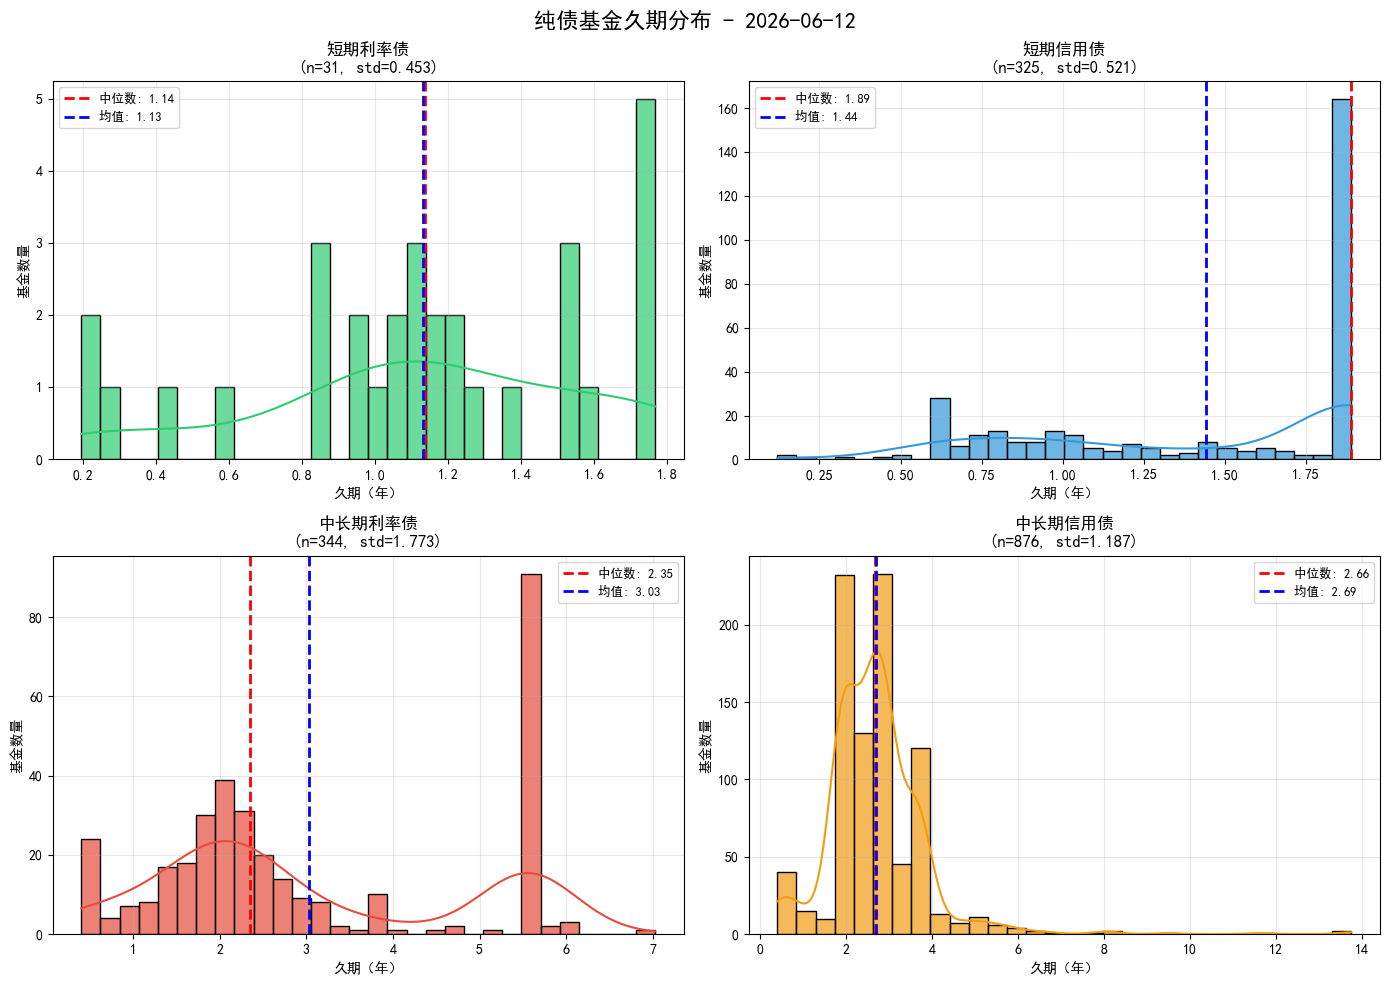


久期分布图已保存为: 久期分布图_20260612.png


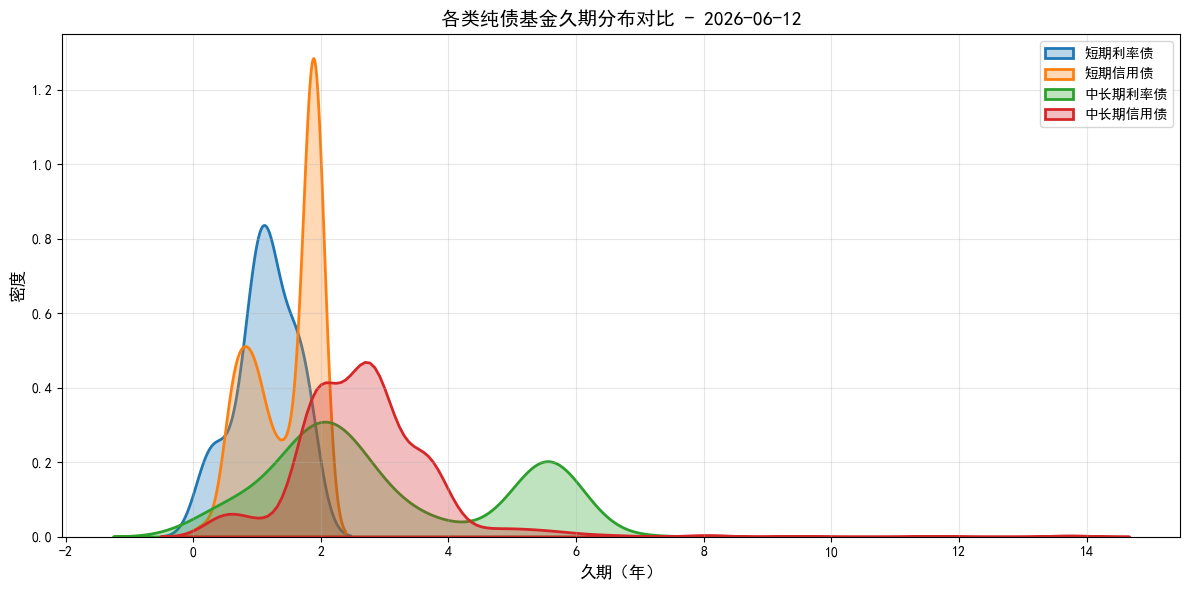

久期分布对比图已保存为: 久期分布对比图_20260612.png


In [12]:
# 绘制久期分布频率直方图
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 创建图表
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'纯债基金久期分布 - {target_date}', fontsize=16, fontweight='bold')

# 绘制各类型基金的久期分布
plot_configs = [
    ('short', 'rate', '短期利率债', axes[0, 0]),
    ('short', 'credit', '短期信用债', axes[0, 1]),
    ('medium_long', 'rate', '中长期利率债', axes[1, 0]),
    ('medium_long', 'credit', '中长期信用债', axes[1, 1]),
]

colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

for idx, (fund_type, bond_type, title, ax) in enumerate(plot_configs):
    mask = (results_df['fund_type'] == fund_type) & (results_df['bond_type'] == bond_type)
    subset = results_df[mask]
    
    if len(subset) > 0:
        durations = subset['duration'].values
        
        # 绘制直方图和KDE
        sns.histplot(durations, bins=30, kde=True, ax=ax, color=colors[idx], alpha=0.7)
        
        # 添加统计信息
        median = np.median(durations)
        mean = np.mean(durations)
        std = np.std(durations)
        
        ax.axvline(median, color='red', linestyle='--', linewidth=2, label=f'中位数: {median:.2f}')
        ax.axvline(mean, color='blue', linestyle='--', linewidth=2, label=f'均值: {mean:.2f}')
        
        ax.set_title(f'{title}\n(n={len(durations)}, std={std:.3f})', fontsize=12)
        ax.set_xlabel('久期（年）', fontsize=10)
        ax.set_ylabel('基金数量', fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, f'{title}\n无数据', ha='center', va='center', fontsize=14)
        ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.savefig(f'久期分布图_{target_date.replace("-", "")}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n久期分布图已保存为: 久期分布图_{target_date.replace("-", "")}.png')

# 绘制总体分布对比图
fig, ax = plt.subplots(figsize=(12, 6))

for idx, (fund_type, bond_type, title, _) in enumerate(plot_configs):
    mask = (results_df['fund_type'] == fund_type) & (results_df['bond_type'] == bond_type)
    subset = results_df[mask]
    
    if len(subset) > 0:
        durations = subset['duration'].values
        sns.kdeplot(durations, label=title, ax=ax, fill=True, alpha=0.3, linewidth=2)

ax.set_title(f'各类纯债基金久期分布对比 - {target_date}', fontsize=14, fontweight='bold')
ax.set_xlabel('久期（年）', fontsize=12)
ax.set_ylabel('密度', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'久期分布对比图_{target_date.replace("-", "")}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'久期分布对比图已保存为: 久期分布对比图_{target_date.replace("-", "")}.png')